In [ ]:
import numpy as np
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVR  # Corrected import statement
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_dir = '/content/drive/MyDrive/017'

batch_size = 8
image_size = (224, 224)

# Increase the amount of augmentation
datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=20,  # Rotate images randomly up to 20 degrees
    width_shift_range=0.2,  # Shift width of images randomly up to 20%
    height_shift_range=0.2,  # Shift height of images randomly up to 20%
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',  # Fill mode for filling in newly created pixels
    validation_split=0.2  # Split 20% of the data for validation
)


train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'  # Use the training split
)

validation_generator = datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'  # Use the validation split
)


Found 400 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# Assuming you have a DirectoryIterator object named train_data

# Extract data and labels from the DirectoryIterator object
X = []
y = []
for _ in range(len(train_generator)):
    data_batch, label_batch = train_generator.next()
    X.append(data_batch)
    y.extend(label_batch)

# Convert list of arrays to a single numpy array
X = np.concatenate(X)
y = np.array(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Reshape image data to 2D arrays (flatten each image)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# PCA for feature extraction
pca = PCA(n_components=10)  # You can adjust the number of components as needed
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)

# **SVM**

In [ ]:
# SVM Classifier with PCA
svm_classifier = svm.SVC(kernel='linear')
svm_classifier.fit(X_train_pca, y_train)
svm_predictions = svm_classifier.predict(X_test_pca)
svm_accuracy = accuracy_score(y_test, svm_predictions)
print("SVM Accuracy with PCA:", svm_accuracy)

SVM Accuracy with PCA: 0.9125


SVM Accuracy with PCA: 0.9125


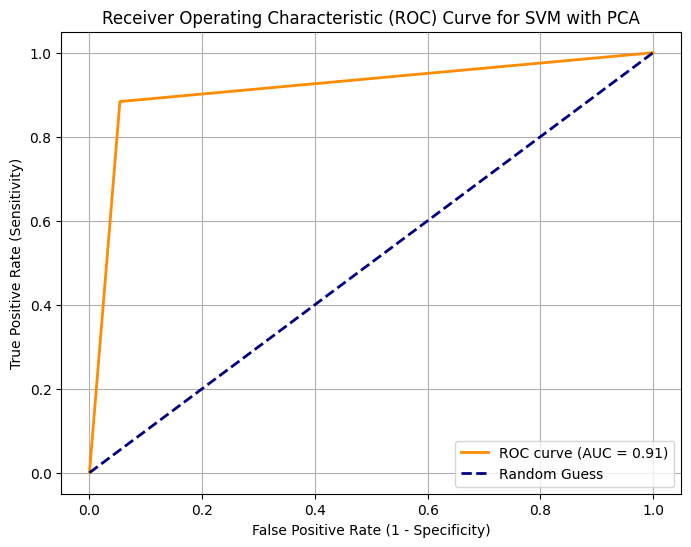

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn import svm
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# SVM Classifier with PCA
svm_classifier = svm.SVC(kernel='linear')
svm_classifier.fit(X_train_pca, y_train)
svm_predictions = svm_classifier.predict(X_test_pca)
svm_accuracy = accuracy_score(y_test, svm_predictions)
print("SVM Accuracy with PCA:", svm_accuracy)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, svm_predictions)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve for SVM with PCA')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

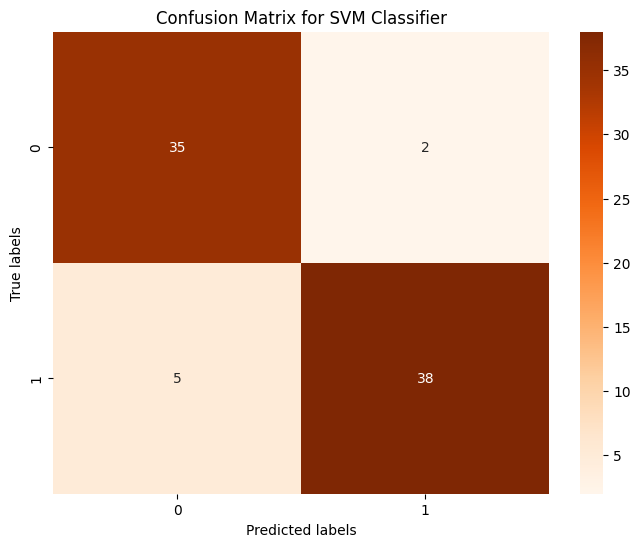


Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.95      0.91        37
         1.0       0.95      0.88      0.92        43

    accuracy                           0.91        80
   macro avg       0.91      0.91      0.91        80
weighted avg       0.92      0.91      0.91        80



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Calculate the confusion matrix
conf_matrix_svm = confusion_matrix(y_test, svm_predictions)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svm, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix for SVM Classifier")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

# Generate and print classification report
print("\nClassification Report:")
print(classification_report(y_test, svm_predictions))

# **KNN**

In [ ]:
# KNN Classifier with PCA
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(X_train_pca, y_train)
knn_predictions = knn_classifier.predict(X_test_pca)
knn_accuracy = accuracy_score(y_test, knn_predictions)
print("KNN Accuracy with PCA:", knn_accuracy)

KNN Accuracy with PCA: 0.95


KNN Accuracy with PCA: 0.95


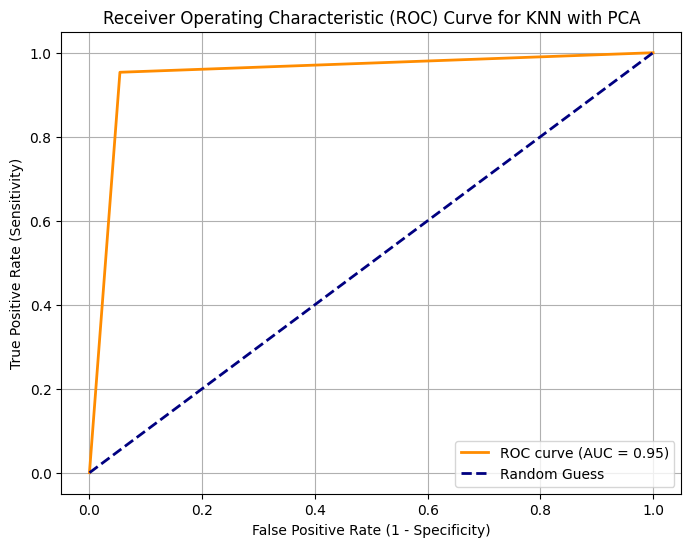

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# Assuming X_train_pca, X_test_pca, y_train, y_test are defined
# KNN Classifier with PCA
KNN_classifier = KNeighborsClassifier()
KNN_classifier.fit(X_train_pca, y_train)
KNN_predictions = KNN_classifier.predict(X_test_pca)
KNN_accuracy = accuracy_score(y_test, KNN_predictions)
print("KNN Accuracy with PCA:", KNN_accuracy)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, KNN_predictions)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve for KNN with PCA')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


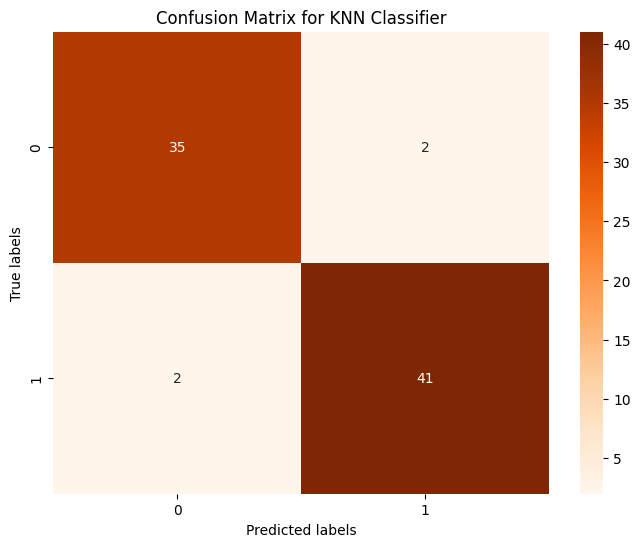


Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.95      0.95        37
         1.0       0.95      0.95      0.95        43

    accuracy                           0.95        80
   macro avg       0.95      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Calculate the confusion matrix
conf_matrix_KNN = confusion_matrix(y_test, knn_predictions)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_KNN, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix for KNN Classifier")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

# Generate and print classification report
print("\nClassification Report:")
print(classification_report(y_test, knn_predictions))

# **DT**

In [ ]:
# DecisionTreeClassifier Classifier with PCA

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

# Create a DecisionTreeClassifier object
DecisionTreeClassifier_classifier = DecisionTreeClassifier()

# Train the classifier with the PCA transformed training data
DecisionTreeClassifier_classifier.fit(X_train_pca, y_train)

# Make predictions on the test data
DecisionTreeClassifier_predictions = DecisionTreeClassifier_classifier.predict(X_test_pca)

# Calculate the accuracy of the predictions
DecisionTreeClassifier_accuracy = accuracy_score(y_test, DecisionTreeClassifier_predictions)

print("DecisionTreeClassifier Accuracy with PCA:", DecisionTreeClassifier_accuracy)

DecisionTreeClassifier Accuracy with PCA: 0.9375


DT Accuracy with PCA: 0.9375


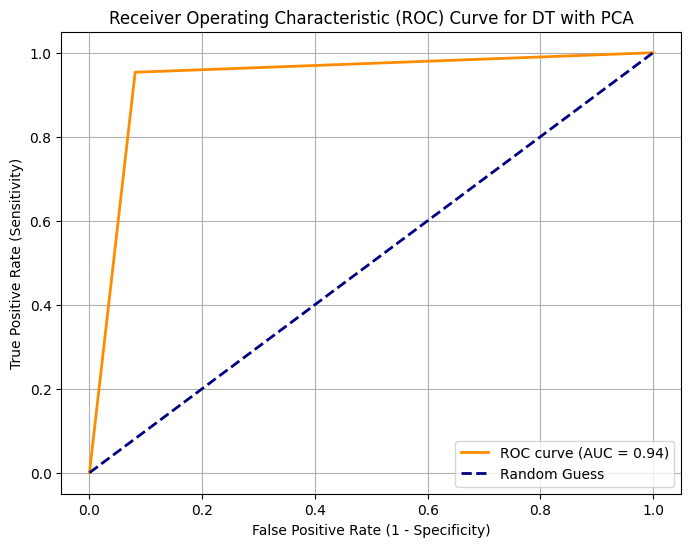

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# Assuming X_train_pca, X_test_pca, y_train, y_test are defined
# DT Classifier with PCA
DT_classifier = DecisionTreeClassifier()
DT_classifier.fit(X_train_pca, y_train)
DT_predictions = DT_classifier.predict(X_test_pca)
DT_accuracy = accuracy_score(y_test, DT_predictions)
print("DT Accuracy with PCA:", DT_accuracy)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, DT_predictions)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve for DT with PCA')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

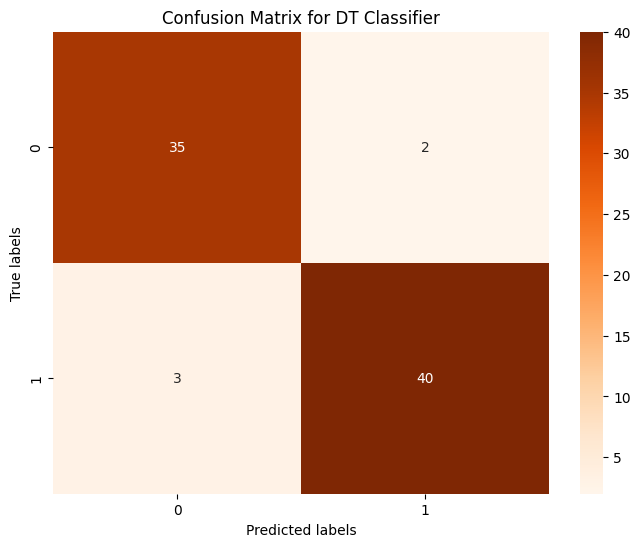


Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93        37
         1.0       0.93      0.95      0.94        43

    accuracy                           0.94        80
   macro avg       0.94      0.94      0.94        80
weighted avg       0.94      0.94      0.94        80



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Calculate the confusion matrix
conf_matrix_DT = confusion_matrix(y_test, DecisionTreeClassifier_predictions)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_DT, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix for DT Classifier")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

# Generate and print classification report
print("\nClassification Report:")
print(classification_report(y_test, DT_predictions))

# **LR**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
# LogisticRegression Classifier with PCA


# Creat a LogisticRegression object
LogisticRegression_classifier = LogisticRegression()

# Train the classifier with the PCA transformed training data
LogisticRegression_classifier.fit(X_train_pca, y_train)

# Make predictions on the test data
LogisticRegression_predictions = LogisticRegression_classifier.predict(X_test_pca)


#Calculate the accuracy of the predictions
LogisticRegression_accuracy = accuracy_score(y_test, LogisticRegression_predictions)

print("LogisticRegression Accuracy with PCA:", LogisticRegression_accuracy)

LogisticRegression Accuracy with PCA: 0.9125


LR Accuracy with PCA: 0.9125


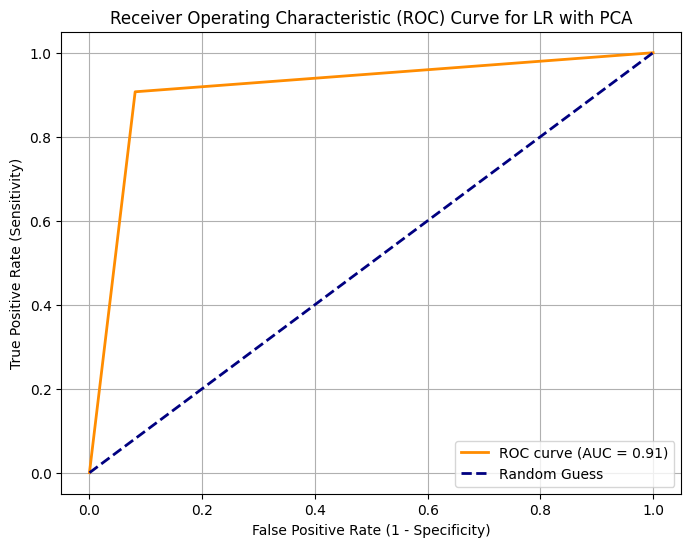

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# Assuming X_train_pca, X_test_pca, y_train, y_test are defined
# Logistic Regression Classifier with PCA
LR_classifier = LogisticRegression()
LR_classifier.fit(X_train_pca, y_train)
LR_predictions = LR_classifier.predict(X_test_pca)
LR_accuracy = accuracy_score(y_test, LR_predictions)
print("LR Accuracy with PCA:", LR_accuracy)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, LR_predictions)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve for LR with PCA')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

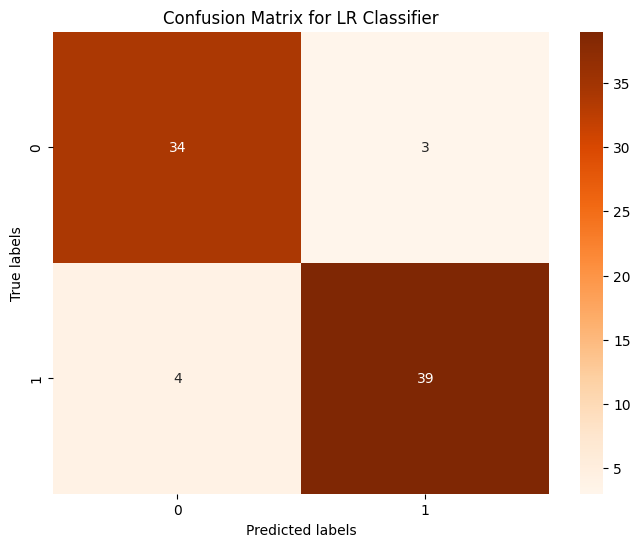


Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.92      0.91        37
         1.0       0.93      0.91      0.92        43

    accuracy                           0.91        80
   macro avg       0.91      0.91      0.91        80
weighted avg       0.91      0.91      0.91        80



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Calculate the confusion matrix
conf_matrix_LR = confusion_matrix(y_test, LogisticRegression_predictions)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_LR, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix for LR Classifier")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

# Generate and print classification report
print("\nClassification Report:")
print(classification_report(y_test, LR_predictions))

### **LS-SVM**

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

# Define and train LS-SVM classifier with PCA
svm_linear = LinearSVC()
svm_linear.fit(X_train_pca, y_train)

# Predict using the trained model
y_pred_svm_linear = svm_linear.predict(X_test_pca)

# Evaluate accuracy
accuracy_svm_linear = accuracy_score(y_test, y_pred_svm_linear)
print("LS-SVM with PCA Accuracy:", accuracy_svm_linear)


LS-SVM with PCA Accuracy: 0.925


/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LS-SVM Accuracy with PCA: 0.925


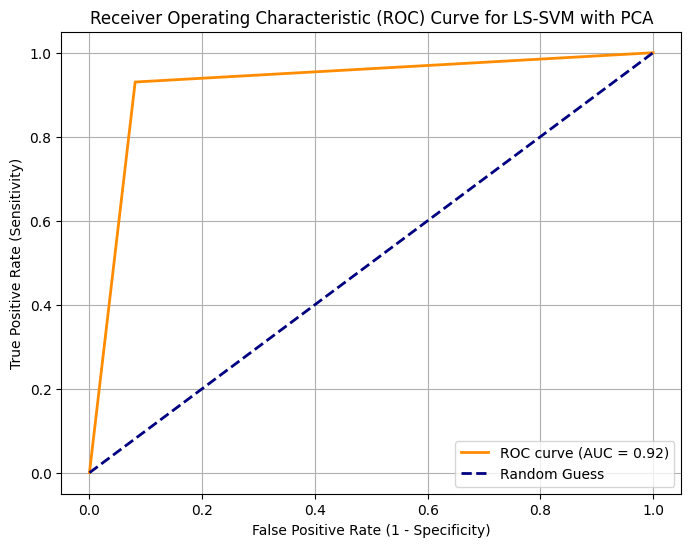

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.svm import LinearSVC
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# Assuming X_train_pca, X_test_pca, y_train, y_test are defined
# Assuming LS_SVM_predictions is the output of LS-SVM classifier

# Instantiate LS-SVM classifier
LS_SVM_classifier = LinearSVC()

# Fit LS-SVM classifier
LS_SVM_classifier.fit(X_train_pca, y_train)

# Predict using LS-SVM classifier
LS_SVM_predictions = LS_SVM_classifier.predict(X_test_pca)

# Compute accuracy
LS_SVM_accuracy = accuracy_score(y_test, LS_SVM_predictions)
print("LS-SVM Accuracy with PCA:", LS_SVM_accuracy)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, LS_SVM_predictions)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve for LS-SVM with PCA')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()



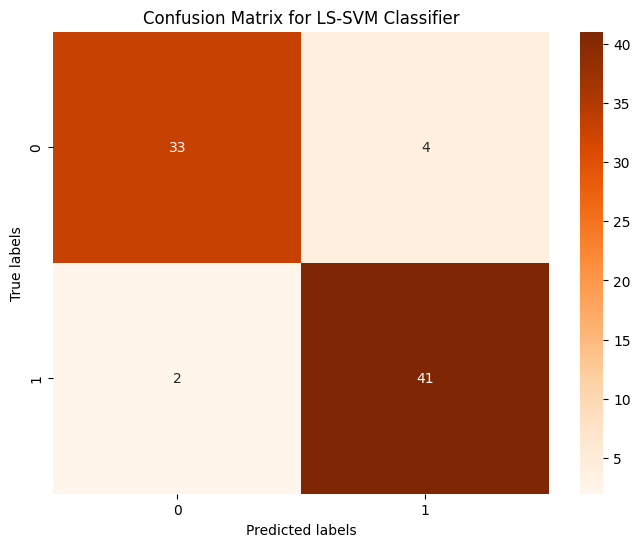


Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.89      0.92        37
         1.0       0.91      0.95      0.93        43

    accuracy                           0.93        80
   macro avg       0.93      0.92      0.92        80
weighted avg       0.93      0.93      0.92        80



In [ ]:
# Assuming LS-SVM predictions are stored in a variable named 'LS_SVM_predictions'

# Make predictions using LS-SVM classifier
LS_SVM_predictions = svm_linear.predict(X_test_pca)  # Assuming svm_linear is the LS-SVM classifier

# Calculate the confusion matrix
conf_matrix_LS_SVM = confusion_matrix(y_test, LS_SVM_predictions)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_LS_SVM, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix for LS-SVM Classifier")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

# Generate and print classification report
print("\nClassification Report:")
print(classification_report(y_test, LS_SVM_predictions))

